# **`Inatel - C24 (Inteligência Artificial) - 2026/1`**

# <font color='green'>**Atividade 06: Classificação**</font>

## <font color='#2D9CDB'>**LEIA ATENTAMENTE AS INSTRUÇÕES A SEGUIR**</font>
- Importe este notebook no [Google Colab](https://colab.research.google.com/) para resolver os exercícios;
- Consulte o material disponibilizado pelo Prof. Felipe Figueiredo para revisar os conceitos;
- Utilize os recursos disponíveis na Internet (documentações e artigos científicos) para complementar seus estudos;
- <font color='red'>**A ATIVIDADE DEVERÁ SER REALIZADA COM O [MONITOR](mailto:matheus.botelho@ges.inatel.br) EM UM DOS SEGUINTES HORÁRIOS:**</font>

| Monitor                       | Dia           | Hora                               | Local           |
|-------------------------------|---------------|------------------------------------|---------------- |
| Matheus Botelho Sampaio Netto | Terça-feira   | <font color='orange'>17:30</font>  | 1.4 (prédio VI) |
| Matheus Botelho Sampaio Netto | Quinta-feira  | <font color='orange'>17:30</font>  | 1.4 (prédio VI) |
| Matheus Botelho Sampaio Netto | Sábado        | <font color='#2D9CDB'>10:00</font> | Teams (ao vivo) |
| Matheus Botelho Sampaio Netto | Sábado        | <font color='#2D9CDB'>13:30</font> | Teams (ao vivo) |

- <font color='red'>**NÃO**</font> remova as células de Código já presentes neste notebook;
- <font color='red'>**NÃO**</font> modifique as células de Markdown (em <font color='green'>verde</font> ou <font color='#2D9CDB'>azul</font>) presentes neste notebook;
- Após cada questão, há uma célula para você implementar e responder a questão;
- É permitido adicionar mais células (de código ou markdown) antes da próxima pergunta;
- Caso precise utilizar bibliotecas que não estão instaladas nativamente no Colab, inclua uma célula de código com o comando de instalação.</font>
  - Exemplo: `!pip install nome_da_biblioteca`
- <font color='red'>**Renomeie os termos `LL` para `sua_turma_de_laboratorio` e `MMMM` para `seu_numero_de_matricula` no nome do arquivo.**</font>
  - Exemplo: `C24_2026_1_L1_Atividade_06_1234.ipynb`)
- <font color='magenta'>**Faça download do notebook com a resolução no Google Colab, mantendo a saída de todas as células, e anexe-o à tarefa do Teams.**</font>

# <font color='green'><u><b>Preparação</b></u></font>

In [4]:
!pip install numpy pandas matplotlib seaborn scikit-learn ucimlrepo

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# <font color='green'><u><b>Parte 1 - Classificação Binária</b></u></font>

### <font color='#2D9CDB'>Acesse o link indicado e, em um único parágrafo, descreva brevemente o dataset, incluindo: domínio de aplicação, objetivo da base de dados e o tipo de informações que ela contém.</font>
- #### <font color='#2D9CDB'>Iranian Churn Dataset (2020). UCI Machine Learning Repository.</font>
  - #### <font color='#2D9CDB'>https://doi.org/10.24432/C5JW3Z</font>
  - #### <font color='#2D9CDB'>https://archive-beta.ics.uci.edu/dataset/563/iranian+churn+dataset</font>

O dataset possui dados de uma empresa iraniana de telecomunicações durante um período de 12 meses, com um total de 3150 linhas, cada uma representando um cliente, e 13 colunas. Os atributos são falhas de chamada, frequência de envio de SMS, número de reclamações, número de chamadas distintas, duração da assinatura, grupo de idade, valor da assinatura, tipo de serviço, segundos de uso, entre outros. A análise desse dataset por ser útil para identificar quais fatores resultaram na perda do cliente.

In [ ]:
# fetch dataset
ds = fetch_ucirepo(id=563)

# metadata
display(ds.metadata)

# variable information
display(ds.variables)

# data (as pandas dataframe)
df = pd.concat([ds.data.features, ds.data.targets], axis='columns')

{'uci_id': 563,
 'name': 'Iranian Churn',
 'repository_url': 'https://archive.ics.uci.edu/dataset/563/iranian+churn+dataset',
 'data_url': 'https://archive.ics.uci.edu/static/public/563/data.csv',
 'abstract': "This dataset is randomly collected from an Iranian telecom company's database over a period of 12 months.",
 'area': 'Business',
 'tasks': ['Classification', 'Regression'],
 'characteristics': ['Multivariate'],
 'num_instances': 3150,
 'num_features': 13,
 'feature_types': ['Integer'],
 'demographics': ['Age'],
 'target_col': ['Churn'],
 'index_col': None,
 'has_missing_values': 'no',
 'missing_values_symbol': None,
 'year_of_dataset_creation': 2020,
 'last_updated': 'Sat Mar 09 2024',
 'dataset_doi': '10.24432/C5JW3Z',
 'creators': [],
 'intro_paper': None,
 'additional_info': {'summary': 'This dataset is randomly collected from an Iranian telecom companyâ€™s database over a period of 12 months. A total of 3150 rows of data, each representing a customer, bear information for 13

,name,role,type,demographic,description,units,missing_values
0,Call Failure,Feature,Integer,None,None,None,no
1,Complains,Feature,Binary,None,None,None,no
2,Subscription Length,Feature,Integer,None,None,None,no
3,Charge Amount,Feature,Integer,None,None,None,no
4,Seconds of Use,Feature,Integer,None,None,None,no
5,Frequency of use,Feature,Integer,None,None,None,no
6,Frequency of SMS,Feature,Integer,None,None,None,no
7,Distinct Called Numbers,Feature,Integer,None,None,None,no
8,Age Group,Feature,Integer,Age,None,None,no
9,Tariff Plan,Feature,Integer,None,None,None,no


### <font color='#2D9CDB'>Q1) Exiba as primeiras linhas do dataframe, verifique suas dimensões e identifique a variável alvo (`TARGET_COLUMN`), respondendo com base nos resultados obtidos: quantas amostras e atributos o dataset possui, qual é o nome da variável alvo e se o problema é de classificação binária (justifique observando os valores únicos da variável alvo).</font>

In [5]:
display(df.head())

,Call Failure,Complains,Subscription Length,Charge Amount,Seconds of Use,Frequency of use,Frequency of SMS,Distinct Called Numbers,Age Group,Tariff Plan,Status,Age,Customer Value,Churn
0,8,0,38,0,4370,71,5,17,3,1,1,30,197.640,0
1,0,0,39,0,318,5,7,4,2,1,2,25,46.035,0
2,10,0,37,0,2453,60,359,24,3,1,1,30,1536.520,0
3,10,0,38,0,4198,66,1,35,1,1,1,15,240.020,0
4,3,0,38,0,2393,58,2,33,1,1,1,15,145.805,0


In [6]:
print("Dimensões do dataframe:", df.shape)

Dimensões do dataframe: (3150, 14)


In [8]:
TARGET_COLUMN = "Churn"

O dataset poussui 3150 amostras e 13 atributos (sendo o Churn) a variável alvo. Trate-se sim de um problema de classificação binária, uma vez que essa variável assume apenas dois valores, que indicam clientes que cancelaram ou não o serviço.



### <font color='#2D9CDB'>Q2) Plote a distribuição da variável alvo utilizando o gráfico fornecido e, com base no resultado obtido, analise a proporção entre as classes para determinar se o dataset é balanceado ou desbalanceado, justificando sua resposta a partir da contagem de amostras em cada classe.</font>

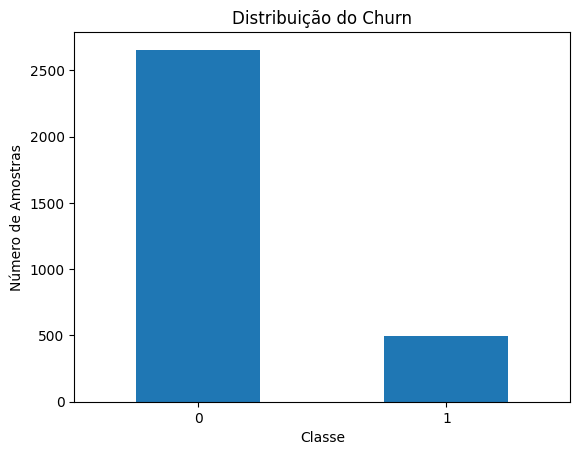

Churn
0    2655
1     495
Name: count, dtype: int64


In [11]:
class_counts = df[TARGET_COLUMN].value_counts()

class_counts.plot(kind='bar')

plt.title('Distribuição do Churn')
plt.xlabel('Classe')
plt.ylabel('Número de Amostras')
plt.xticks(rotation=0)

plt.show()

print(class_counts)

In [13]:
#O dataset é desbalanceado, uma vez que há 2655 registros com valor 0 e 495 registros com valor 1. São mais de 5x mais registros com valor 0 do que com valor 1.

### <font color='#2D9CDB'>Q3) Gere a matriz de correlação entre os atributos do dataset e a variável alvo utilizando o gráfico fornecido e, com base nos valores apresentados, identifique quais atributos possuem maior correlação (positiva ou negativa) com a variável alvo, indicando quais podem ser mais relevantes para o problema de classificação.</font>

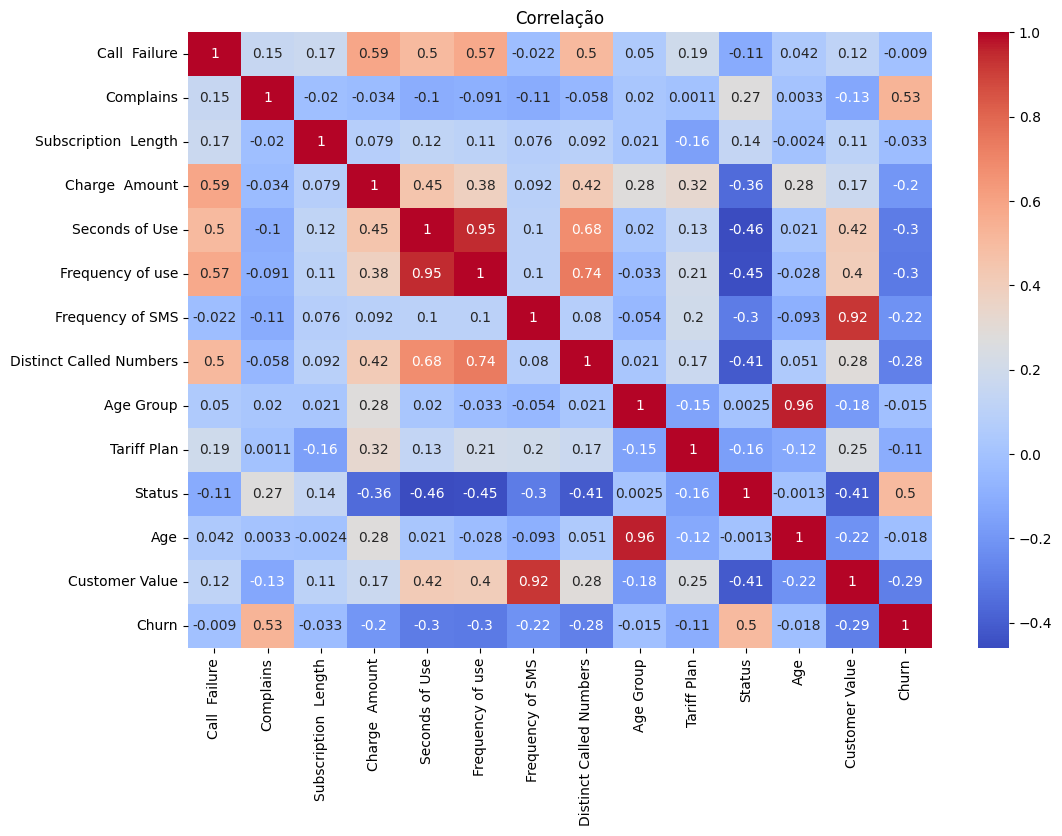

Churn                      1.000000
Complains                  0.532053
Status                     0.498976
Call  Failure             -0.008987
Age Group                 -0.014550
Age                       -0.017705
Subscription  Length      -0.032588
Tariff Plan               -0.105853
Charge  Amount            -0.202305
Frequency of SMS          -0.220754
Distinct Called Numbers   -0.278867
Customer Value            -0.289144
Seconds of Use            -0.298935
Frequency of use          -0.303337
Name: Churn, dtype: float64


In [14]:
df_numerico = df.select_dtypes(include=['int64', 'float64'])

corr = df_numerico.corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title('Correlação')
plt.show()

print(corr[TARGET_COLUMN].sort_values(ascending=False))

### <font color='#2D9CDB'>Q4) Aplique a técnica de Análise de Componentes Principais (PCA) para projetar os dados em duas dimensões e gere um gráfico de dispersão (scatter plot) utilizando as duas primeiras componentes principais, colorindo os pontos de acordo com a variável alvo; antes de aplicar o PCA, padronize os dados utilizando `StandardScaler`; em seguida, com base na visualização obtida, analise se há separação entre as classes e justifique sua resposta considerando a presença ou não de sobreposição entre os grupos.</font>

### <font color='#2D9CDB'>Q5) Separe o dataset em variáveis de entrada (`X`) e variável alvo (`y`), divida os dados em conjuntos de treino e teste utilizando `train_test_split` (com 20% para teste) e `random_state=42`, e aplique a padronização dos atributos com `StandardScaler`; em seguida, explique por que a padronização é importante nesse contexto e por que o `fit` deve ser aplicado apenas no conjunto de treino.

### <font color='#2D9CDB'>Q6) Treine um modelo de regressão logística utilizando os dados de treino (`X_train`, `y_train`) e, após o treinamento, verifique se o modelo convergiu corretamente; em seguida, descreva qual é o papel desse modelo no contexto do problema e o que ele está aprendendo a partir dos dados.</font>

### <font color='#2D9CDB'>Q7) Utilize o modelo treinado para calcular as probabilidades previstas para o conjunto de teste (`predict_proba`) e exiba algumas delas; em seguida, interprete os valores obtidos explicando o que cada coluna representa e analise se o modelo está fazendo previsões com alta ou baixa confiança, com base na proximidade dos valores de 0 e 1.</font>

### <font color='#2D9CDB'>Q8) Utilize as probabilidades previstas para gerar classificações com dois limiares diferentes (0.5 e 0.7) e compare os resultados obtidos; em seguida, analise como a alteração do limiar afeta as previsões do modelo, especialmente em relação à quantidade de falsos positivos e falsos negativos.</font>

### <font color='#2D9CDB'>Q9) Calcule as métricas de desempenho (acurácia, precisão, recall e F1-score) e a matriz de confusão para os dois limiares de decisão (0.5 e 0.7) utilizando a função fornecida e, com base nos resultados obtidos, compare o desempenho do modelo, identificando qual métrica foi mais impactada pela mudança do limiar e discutindo o trade-off observado entre precisão e recall.</font>

# <font color='green'><u><b>Parte 2 - Classificação Multiclasse</b></u></font>

### <font color='#2D9CDB'>Acesse o link indicado e, em um único parágrafo, descreva brevemente o dataset, incluindo: domínio de aplicação, objetivo da base de dados e o tipo de informações que ela contém.</font>
- #### <font color='#2D9CDB'>Blackard, J. (1998). Covertype Dataset. UCI Machine Learning Repository.</font>
  - #### <font color='#2D9CDB'>https://doi.org/10.24432/C50K5N</font>
  - #### <font color='#2D9CDB'>https://archive-beta.ics.uci.edu/dataset/31/covertype</font>

In [ ]:
# fetch dataset
ds = fetch_ucirepo(id=31)

# metadata
display(ds.metadata)

# variable information
display(ds.variables)

# data (as pandas dataframe)
df = pd.concat([ds.data.features, ds.data.targets], axis='columns').sample(frac=0.10, random_state=42)

### <font color='#2D9CDB'>Q10) Exiba as primeiras linhas do dataframe, verifique suas dimensões e identifique a variável alvo (`TARGET_COLUMN`), respondendo com base nos resultados obtidos: quantas amostras e atributos o dataset possui, qual é o nome da variável alvo e se o problema é de classificação binária (justifique observando os valores únicos da variável alvo).</font>

In [ ]:
TARGET_COLUMN = None # preencher

### <font color='#2D9CDB'>Q11) Plote a distribuição da variável alvo utilizando o gráfico fornecido e, com base no resultado obtido, analise a proporção entre as classes para determinar se o dataset é balanceado ou desbalanceado, justificando sua resposta a partir da contagem de amostras em cada classe.</font>

### <font color='#2D9CDB'>Q12) Gere a correlação entre os atributos e a variável alvo, ordene os valores e plote um gráfico de barras horizontais; destaque, no gráfico, os atributos com maior correlação em valor absoluto utilizando linhas de referência em |r| = 0.2 (valor adotado como um limiar heurístico para indicar correlações moderadas); em seguida, com base nos resultados, identifique quais variáveis podem ser mais relevantes para o modelo. Opcionalmente, pode-se imprimir os valores de correlação para facilitar a verificação numérica dos resultados e complementar a análise visual do gráfico.</font>

### <font color='#2D9CDB'>Q13) Aplique a técnica de Análise de Componentes Principais (PCA) para projetar os dados em duas dimensões e gere um gráfico de dispersão (scatter plot) utilizando as duas primeiras componentes principais, colorindo os pontos de acordo com a variável alvo; em seguida, com base na visualização obtida, analise se há separação entre as classes e justifique sua resposta considerando a presença ou não de sobreposição entre os grupos.</font>

### <font color='#2D9CDB'>Q14) Separe o dataset em variáveis de entrada (`X`) e variável alvo (`y`), divida os dados em conjuntos de treino e teste utilizando `train_test_split` (com 20% para teste) e `random_state=42`, aplique a padronização dos atributos com `StandardScaler` e instancie um objeto de validação cruzada `KFold` com 5 divisões; em seguida, explique por que a validação cruzada (k-fold cross-validation) é importante para avaliar o desempenho de modelos de classificação.</font>

### <font color='#2D9CDB'>Q15) Utilize o objeto `KFold` instanciado anteriormente para treinar e avaliar um modelo de regressão logística multiclasse ao longo dos 5 folds no conjunto de treino, aplicando a padronização dentro de cada fold; durante o treinamento, exiba o número de iterações (`n_iter_`) em cada fold e verifique se o modelo convergiu corretamente; em seguida, reporte a média das métricas obtidas e descreva o papel do modelo no contexto do problema e o que ele está aprendendo a partir dos dados.</font>

### <font color='#2D9CDB'>Q16) Treine um modelo final de regressão logística utilizando todo o conjunto de treino (`X_train`, `y_train`), aplicando regularização L2 (padrão do `scikit-learn`) com `C=0.01`; em seguida, aplique a padronização adequada e utilize o modelo para calcular as probabilidades previstas no conjunto de teste (`predict_proba`); exiba algumas dessas probabilidades e interprete os valores obtidos, explicando o que cada coluna representa e analisando se o modelo está fazendo previsões com alta ou baixa confiança.</font>

### <font color='#2D9CDB'>Q17) Treine um modelo de regressão logística sem regularização (`penalty=None`) utilizando o mesmo procedimento de padronização e conjunto de treino; em seguida, calcule as probabilidades previstas no conjunto de teste (`predict_proba`), exiba algumas delas (usando os mesmos índices de amostras da questão anterior) e analise os resultados novamente.</font>

### <font color='#2D9CDB'>Q18) Compare as probabilidades previstas pelos modelos com e sem regularização e analise as diferenças observadas, considerando: (i) a concentração das probabilidades em uma única classe, (ii) o nível de confiança das previsões e (iii) possíveis indícios de overfitting; para apoiar sua análise, calcule a confiança média dos modelos (considerando, para cada amostra, a maior probabilidade prevista) e utilize esse valor na comparação.</font>

### <font color='#2D9CDB'>Q19) Utilize o `classification_report` para avaliar o desempenho dos modelos com e sem regularização no conjunto de teste; em seguida, compare os resultados obtidos, analisando as métricas de precisão, recall e F1-score para cada classe e discutindo possíveis diferenças no desempenho entre os modelos.</font>

### <font color='#2D9CDB'>Q20) Calcule a matriz de confusão normalizada (por linha, com duas casas de precisão) para os modelos com e sem regularização no conjunto de teste; em seguida, plote ambas as matrizes e compare os resultados, analisando quais classes são melhor classificadas, quais apresentam maior confusão e como a regularização impacta o desempenho entre as classes.</font>